# 00 - Introducción a OpenBB: Descarga y Exploración de Datos

**Capítulo**: 00 - Fundamentos

**Objetivo**: Familiarizarse con OpenBB SDK para descargar y explorar datos históricos de mercado.

---

## 1. Setup e importaciones

In [1]:
import sys
sys.path.insert(0, '../..')

from openbb import obb
import pandas as pd
import matplotlib.pyplot as plt

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 10)
print('Setup completado correctamente ✓')

Extensions to add: benzinga@1.6.1, bls@1.3.1, cftc@1.4.1, commodity@1.5.2, congress_gov@1.2.3, crypto@1.6.2, currency@1.6.2, derivatives@1.6.2, econdb@1.5.1, economy@1.6.2, equity@1.6.2, etf@1.6.2, federal_reserve@1.6.2, fixedincome@1.6.2, fmp@1.6.1, fred@1.6.1, government_us@1.6.1, imf@2.1.3, imf_utils@2.1.3, index@1.6.2, intrinio@1.6.1, news@1.6.2, oecd@1.6.1, regulators@1.6.2, sec@1.6.1, tiingo@1.6.1, tradingeconomics@1.6.1, us_eia@1.3.1, uscongress@1.2.3, yfinance@1.6.3

Building...
Setup completado correctamente ✓


## 2. Descarga de datos históricos

Usamos OpenBB para descargar datos de Apple (AAPL) como ejemplo.

In [2]:
# Descargar datos históricos de AAPL (últimos 5 años)
result = obb.equity.price.historical("AAPL", provider="yfinance")
df = result.to_dataframe()

print(f"Registros descargados: {len(df)}")
print(f"Período: {df.index.min()} a {df.index.max()}")
df.head()

Registros descargados: 251
Período: 2025-05-29 a 2026-05-28


,open,high,low,close,volume,dividend
date,,,,,,
2025-05-29,203.580002,203.809998,198.509995,199.949997,51396800,0.0
2025-05-30,199.369995,201.960007,196.779999,200.850006,70819900,0.0
2025-06-02,200.279999,202.130005,200.119995,201.699997,35423300,0.0
2025-06-03,201.350006,203.770004,200.960007,203.270004,46381600,0.0
2025-06-04,202.910004,206.240005,202.100006,202.820007,43604000,0.0


## 3. Exploración básica de datos

In [3]:
# Información general del DataFrame
print("Columnas disponibles:")
print(df.columns.tolist())
print(f"\nTipo de índice: {type(df.index).__name__}")
print(f"\nEstadísticas descriptivas:")
df[['open', 'high', 'low', 'close', 'volume']].describe()

Columnas disponibles:
['open', 'high', 'low', 'close', 'volume', 'dividend']

Tipo de índice: Index

Estadísticas descriptivas:


,open,high,low,close,volume
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,251.315737,253.897331,249.021633,251.496414,4.953441e+07
std,27.466795,27.819491,27.393615,27.740145,1.866671e+07
min,195.940002,197.570007,195.070007,195.639999,1.791060e+07
25%,231.175003,233.250000,229.339996,231.239998,3.939560e+07
50%,257.809998,259.649994,255.429993,258.209991,4.567730e+07
75%,270.974991,273.809998,268.315002,271.205002,5.268855e+07
max,310.679993,313.260010,309.570007,312.510010,1.637413e+08


## 4. Visualización de precios

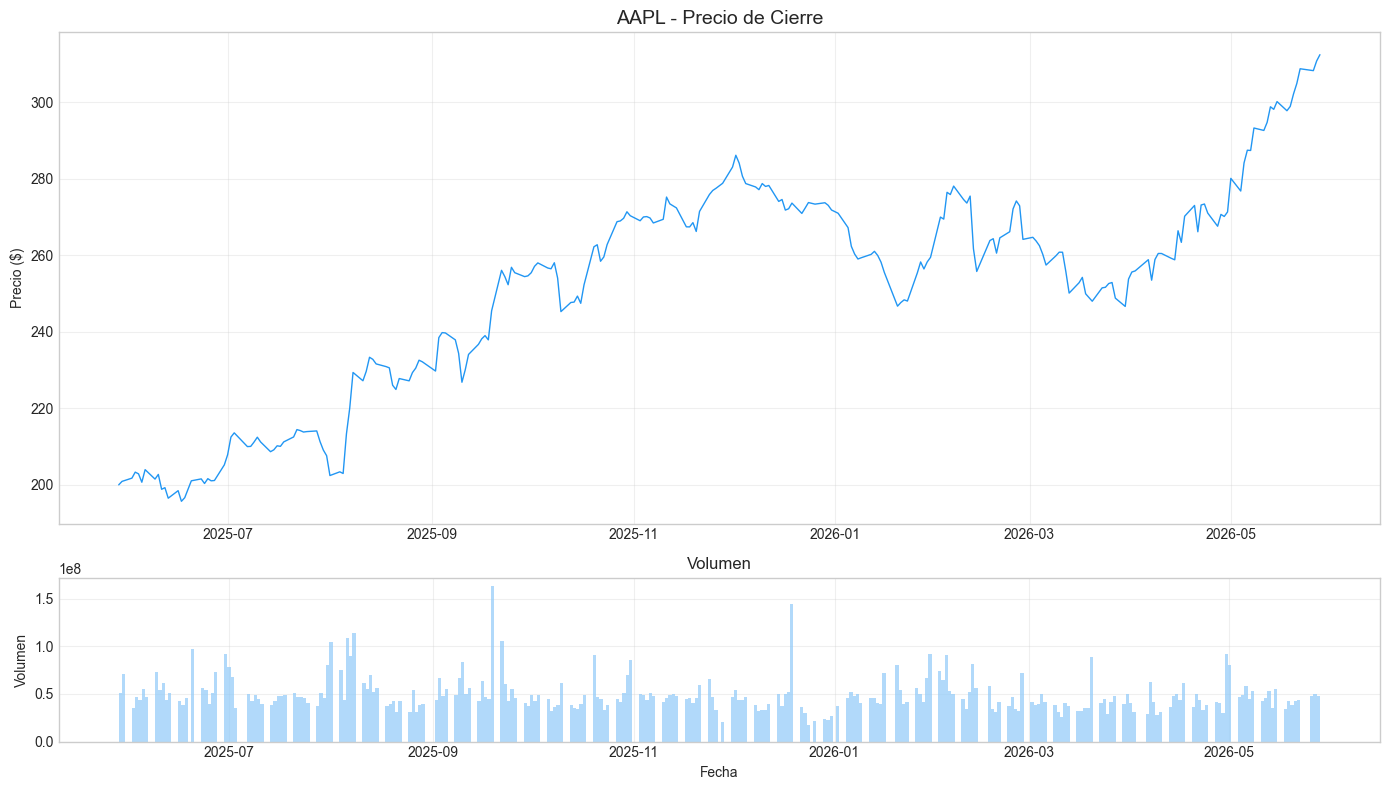

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Precio de cierre
axes[0].plot(df.index, df['close'], linewidth=1, color='#2196F3')
axes[0].set_title('AAPL - Precio de Cierre', fontsize=14)
axes[0].set_ylabel('Precio ($)')
axes[0].grid(True, alpha=0.3)

# Volumen
axes[1].bar(df.index, df['volume'], width=1, color='#90CAF9', alpha=0.7)
axes[1].set_title('Volumen', fontsize=12)
axes[1].set_ylabel('Volumen')
axes[1].set_xlabel('Fecha')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Cálculo de rendimientos

In [5]:
# Rendimiento diario
df['daily_return'] = df['close'].pct_change() * 100

# Rendimiento acumulado
df['cumulative_return'] = (1 + df['close'].pct_change()).cumprod() - 1

print(f"Rendimiento total del período: {df['cumulative_return'].iloc[-1]*100:.2f}%")
print(f"Rendimiento diario promedio: {df['daily_return'].mean():.4f}%")
print(f"Volatilidad diaria (std): {df['daily_return'].std():.4f}%")
print(f"Peor día: {df['daily_return'].min():.2f}%")
print(f"Mejor día: {df['daily_return'].max():.2f}%")

Rendimiento total del período: 56.29%
Rendimiento diario promedio: 0.1884%
Volatilidad diaria (std): 1.3915%
Peor día: -5.00%
Mejor día: 5.09%


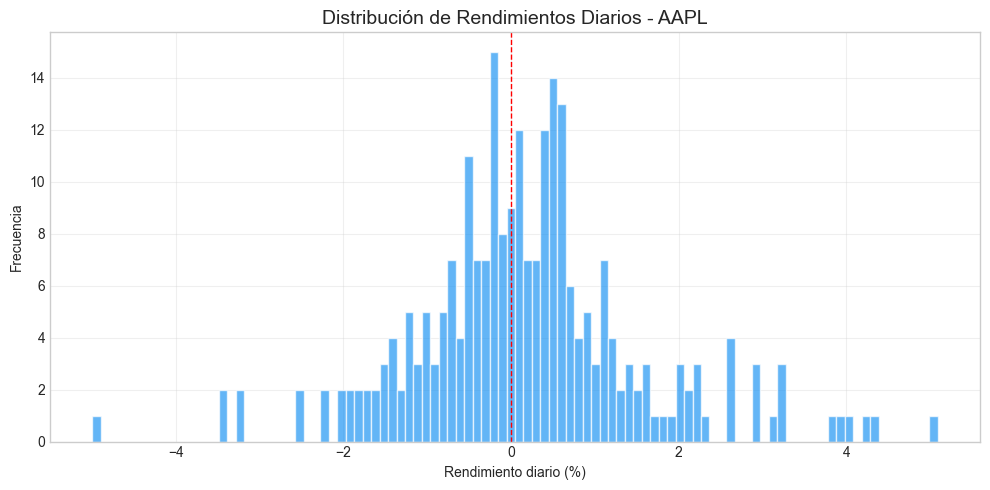

In [6]:
# Distribución de rendimientos diarios
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['daily_return'].dropna(), bins=100, color='#2196F3', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Distribución de Rendimientos Diarios - AAPL', fontsize=14)
ax.set_xlabel('Rendimiento diario (%)')
ax.set_ylabel('Frecuencia')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Usando la librería del curso

El curso incluye utilidades compartidas en `curso/lib/` que simplifican operaciones comunes.

In [7]:
from curso.lib.data import download_historical, detect_gaps

# Descargar con cache automático
df_cached = download_historical("MSFT")
print(f"MSFT - {len(df_cached)} registros descargados")
print(f"Columnas: {df_cached.columns.tolist()}")

# Detectar gaps
gaps = detect_gaps(df_cached)
if len(gaps) > 0:
    print(f"\nGaps detectados (>{5} días):")
    print(gaps)
else:
    print("\nNo se detectaron gaps significativos en los datos.")

MSFT - 1254 registros descargados
Columnas: ['Open', 'High', 'Low', 'Close', 'Volume']

No se detectaron gaps significativos en los datos.


## 7. Descarga de múltiples activos

In [8]:
from curso.lib.data import download_multiple

# Descargar varios tickers del sector salud
tickers_salud = ["JNJ", "PFE", "UNH", "ABBV", "MRK"]
datos = download_multiple(tickers_salud)

print("Datos descargados:")
for ticker, data in datos.items():
    print(f"  {ticker}: {len(data)} registros ({data.index.min().date()} → {data.index.max().date()})")

Datos descargados:
  JNJ: 1254 registros (2021-06-01 → 2026-05-28)
  PFE: 1254 registros (2021-06-01 → 2026-05-28)
  UNH: 1254 registros (2021-06-01 → 2026-05-28)
  ABBV: 1254 registros (2021-06-01 → 2026-05-28)
  MRK: 1254 registros (2021-06-01 → 2026-05-28)


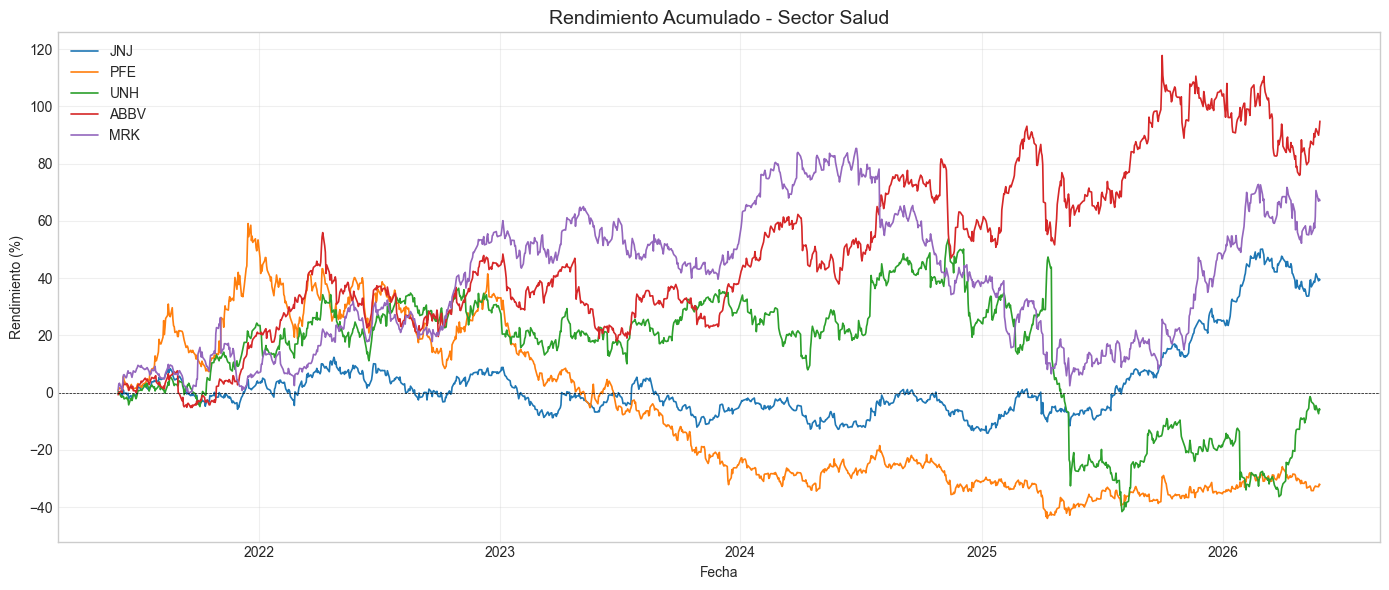

In [9]:
# Comparar rendimiento acumulado de varios activos
fig, ax = plt.subplots(figsize=(14, 6))

for ticker, data in datos.items():
    returns = (1 + data['Close'].pct_change()).cumprod() - 1
    ax.plot(returns.index, returns * 100, linewidth=1.2, label=ticker)

ax.set_title('Rendimiento Acumulado - Sector Salud', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Rendimiento (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

## Resumen

En este notebook hemos aprendido a:

1. ✅ Descargar datos históricos con OpenBB
2. ✅ Explorar la estructura de los datos (OHLCV)
3. ✅ Visualizar precios y volumen
4. ✅ Calcular rendimientos diarios y acumulados
5. ✅ Usar las utilidades del curso (`curso/lib/data.py`)
6. ✅ Descargar y comparar múltiples activos

---

**Siguiente paso**: Completa el cuestionario en `cuestionario.md` y luego avanza al Capítulo 01.